# First Regression/Classification Model

#### Proposed pipeline
`EMG + IMU → preprocessing/features → regression proxy (0–50) → discrete state → bilateral transition validation → accepted motor state`

The data contains:
- 8 EMG channels
- 6 IMUs (left/right thigh, shank, foot)
- each IMU has Accel X/Y/Z and Gyro X/Y/Z
- standing baseline + five-step walking trial

Time/history is used for **state-transition tracking and fault detection**, not future prediction.

In [6]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score, accuracy_score, confusion_matrix

plt.rcParams['figure.figsize'] = (12, 4)
pd.set_option('display.max_columns', 60)
RANDOM_STATE = 42

Matplotlib is building the font cache; this may take a moment.


### 1. Load the Data

In [13]:
STANDING_FILE = "../Data/standing still z.xlsx"
WALKING_FILE = "../Data/Walking z 1.xlsx"

standing = pd.read_excel(STANDING_FILE)
walking = pd.read_excel(WALKING_FILE)

print("Standing:", standing.shape)
print("Walking :", walking.shape)
display(walking.head())

Standing: (32624, 45)
Walking : (12360, 45)


,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
0,0.0000,-2.1386,0.4033,-17.1598,-3.3709,-5.4275,-0.1902,-2.9087,-3.6227,974.1211,34.5459,-264.8926,-17.4844,-0.7046,11.1875,1003.9,-157.7148,-210.8154,-24.3281,-11.7109,0.7275,292.4805,518.0664,804.1992,28.5156,-6.9961,-13.9062,909.1797,-361.8164,-192.6270,-3.1660,22.4062,4.4492,976.5625,119.9951,-235.4736,-18.3438,4.5195,-11.9219,-281.9824,414.5508,878.9062,22.4844,1.6807,-1.5576
1,0.0005,0.3029,-4.4798,-20.5170,-5.2020,-6.0378,-1.1058,-0.4672,-8.8110,973.2422,33.2626,-263.3545,-17.4312,-0.5538,11.0125,1004.4,-157.5073,-209.6069,-24.0219,-11.7094,0.8296,290.9424,517.7246,805.1270,28.2375,-6.9844,-13.8141,909.2285,-362.4268,-192.0654,-3.2521,22.3188,4.4898,976.0742,118.7500,-234.1309,-18.3078,4.4965,-11.9438,-283.6670,414.6729,880.0781,22.6969,1.7061,-1.5552
2,0.0010,2.1341,-10.5837,-22.6533,-6.7280,-5.4275,-2.0214,2.5848,-9.4214,972.3633,31.9794,-261.8164,-17.3781,-0.4029,10.8375,1004.9,-157.2998,-208.3984,-23.7156,-11.7078,0.9316,289.4043,517.3828,806.0547,27.9594,-6.9727,-13.7219,909.2773,-363.0371,-191.5039,-3.3383,22.2313,4.5305,975.5859,117.5049,-232.7881,-18.2719,4.4734,-11.9656,-285.3516,414.7949,881.2500,22.9094,1.7314,-1.5527
3,0.0015,4.2704,-17.2980,-22.6533,-5.8124,-3.5963,-2.3266,4.1107,-8.2006,971.4844,30.6961,-260.2783,-17.3250,-0.2521,10.6625,1005.4,-157.0923,-207.1899,-23.4094,-11.7062,1.0337,287.8662,517.0410,806.9824,27.6812,-6.9609,-13.6297,909.3262,-363.6475,-190.9424,-3.4244,22.1437,4.5711,975.0977,116.2598,-231.4453,-18.2359,4.4504,-11.9875,-287.0361,414.9170,882.4219,23.1219,1.7568,-1.5503
4,0.0020,7.3224,-22.7915,-21.7377,-5.5072,-0.2392,-2.3266,3.5004,-8.2006,970.6055,29.4128,-258.7402,-17.2719,-0.1013,10.4875,1005.9,-156.8848,-205.9814,-23.1031,-11.7047,1.1357,286.3281,516.6992,807.9102,27.4031,-6.9492,-13.5375,909.3750,-364.2578,-190.3809,-3.5105,22.0562,4.6117,974.6094,115.0146,-230.1025,-18.2000,4.4273,-12.0094,-288.7207,415.0391,883.5938,23.3344,1.7822,-1.5479


### 2. Group the Signals from the Dataset

In [15]:
time_col = 'Time_s'
emg_cols = list(walking.columns[1:9])
imu_cols = [c for c in walking.columns if c not in [time_col] + emg_cols]
left_cols = [c for c in imu_cols if '_L_' in c]
right_cols = [c for c in imu_cols if '_R_' in c]

print(f"EMG channels: {len(emg_cols)}")
print(f"IMU columns : {len(imu_cols)}")
print(f"Left IMU    : {len(left_cols)}")
print(f"Right IMU   : {len(right_cols)}")
print("EMG:", emg_cols)

EMG channels: 8
IMU columns : 36
Left IMU    : 18
Right IMU   : 18
EMG: ['Multifidus_R', 'Multifidus_L', 'ExternalOblique_R', 'ExternalOblique_L', 'RectusAbdominis_R', 'RectusAbdominis_L', 'ErectorSpinae_R', 'ErectorSpinae_L']


### 3. Validate the Data points

In [22]:
def quality_report(df, name):
    dt = df[time_col].diff().dropna()
    print(f"--- {name} ---")
    print("Rows / columns:", df.shape)
    print("Missing cells:", int(df.isna().sum().sum()))
    print("Duplicate rows:", int(df.duplicated().sum()))
    display(df.describe())
    print()

quality_report(standing, "Standing baseline")
quality_report(walking, "Walking")



--- Standing baseline ---
Rows / columns: (32624, 45)
Missing cells: 468
Duplicate rows: 0


,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
count,32624.000000,32624.000000,32624.000000,32624.000000,32624.000000,32624.00000,32624.000000,32624.00000,32624.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000,32611.000000
mean,8.154300,-0.019371,-0.090044,-0.364465,0.029039,-0.00224,-0.023093,-0.00262,0.053266,978.620917,29.716522,-201.493739,-0.047586,0.068981,-0.035272,975.838008,-215.992446,-12.747979,0.011365,0.044316,-0.008752,265.288364,402.818604,874.320388,-0.001714,-0.025822,0.023425,933.920025,-301.983224,-190.159578,0.057716,-0.235246,-0.027483,933.978291,262.878600,-240.968979,0.058577,0.049816,0.089971,-305.597508,420.869547,851.419314,-0.003697,0.016967,0.018591
std,4.708103,5.560736,4.383451,5.808970,10.602722,2.29799,6.578318,7.45059,3.410939,13.373879,19.129055,24.613023,3.243143,3.152267,0.847522,2.586647,9.214250,4.976158,0.852384,0.369798,0.511564,1.220152,2.224455,1.310728,0.278672,0.187547,0.143207,13.886536,23.468520,36.973183,6.943517,3.291834,1.327018,3.675939,10.825556,4.977381,0.898564,0.391301,0.635920,1.435222,3.636853,2.073291,0.585246,0.217861,0.148406
min,0.000000,-33.886300,-22.070100,-22.042600,-103.756000,-11.59890,-31.764200,-54.31770,-28.334000,548.828100,-278.564500,-947.265600,-106.125000,-48.781200,-11.359400,944.824200,-262.695300,-39.215100,-9.203100,-1.395500,-2.576200,261.474600,381.591800,866.210900,-1.948200,-1.897500,-0.406200,589.843800,-882.324200,-1437.500000,-98.125000,-50.937500,-31.828100,905.761700,202.636700,-268.798800,-11.109400,-2.939500,-2.658200,-311.767600,392.578100,843.750000,-2.320300,-1.263700,-0.886700
25%,4.077175,-3.061700,-2.842800,-2.815400,-4.262700,-1.22230,-1.855100,-1.82430,-1.476900,977.441400,24.456800,-205.163600,-0.656100,-0.147700,-0.299000,974.316400,-221.600300,-16.640450,-0.297200,-0.185050,-0.236850,264.453100,401.025400,873.486300,-0.118200,-0.090400,-0.064700,932.617200,-306.835900,-195.629900,-0.485500,-0.533400,-0.289600,931.738300,257.177700,-244.482400,-0.265600,-0.183300,-0.223800,-306.543000,419.189500,850.097700,-0.205200,-0.058000,-0.051900
50%,8.154350,-0.009800,-0.096100,-0.373800,-0.905500,-0.00150,-0.023900,0.00690,0.049100,978.613300,27.850300,-201.489300,-0.129700,0.064400,-0.032500,975.488300,-218.383800,-12.367200,-0.027000,0.061900,-0.014600,265.185500,402.905300,874.414100,-0.005700,-0.018000,0.005700,934.228500,-299.877900,-191.894500,0.090200,-0.193800,0.078900,933.398400,263.916000,-241.528300,0.022100,0.041000,0.102900,-305.615200,421.777300,851.074200,-0.013700,0.018600,0.024100
75%,12.231425,3.347400,2.345500,1.762500,4.588000,1.21930,1.502000,2.14320,1.880300,979.736300,31.428500,-198.034700,0.518600,0.247700,0.213650,977.148400,-210.009800,-8.768100,0.257350,0.272700,0.227700,265.918000,404.394500,875.293000,0.108600,0.056000,0.086100,935.791000,-294.921900,-186.352500,0.659700,0.080850,0.358200,935.742200,268.554700,-237.719700,0.392550,0.316800,0.435700,-304.687500,423.242200,852.29490


--- Walking ---
Rows / columns: (12360, 45)
Missing cells: 1500
Duplicate rows: 0


,Time_s,Multifidus_R,Multifidus_L,ExternalOblique_R,ExternalOblique_L,RectusAbdominis_R,RectusAbdominis_L,ErectorSpinae_R,ErectorSpinae_L,Thigh_L_Accel_X,Thigh_L_Accel_Y,Thigh_L_Accel_Z,Thigh_L_Gyro_X,Thigh_L_Gyro_Y,Thigh_L_Gyro_Z,Shank_L_Accel_X,Shank_L_Accel_Y,Shank_L_Accel_Z,Shank_L_Gyro_X,Shank_L_Gyro_Y,Shank_L_Gyro_Z,Foot_L_Accel_X,Foot_L_Accel_Y,Foot_L_Accel_Z,Foot_L_Gyro_X,Foot_L_Gyro_Y,Foot_L_Gyro_Z,Thigh_R_Accel_X,Thigh_R_Accel_Y,Thigh_R_Accel_Z,Thigh_R_Gyro_X,Thigh_R_Gyro_Y,Thigh_R_Gyro_Z,Shank_R_Accel_X,Shank_R_Accel_Y,Shank_R_Accel_Z,Shank_R_Gyro_X,Shank_R_Gyro_Y,Shank_R_Gyro_Z,Foot_R_Accel_X,Foot_R_Accel_Y,Foot_R_Accel_Z,Foot_R_Gyro_X,Foot_R_Gyro_Y,Foot_R_Gyro_Z
count,12360.000000,12360.000000,12360.000000,12360.000000,12360.000000,12360.000000,12360.00000,12360.000000,12360.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12155.000000,12155.000000,12155.000000,12155.000000,12155.000000,12155.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000,12351.000000
mean,3.089201,0.004949,0.103355,0.250528,-0.022170,-0.246093,0.11841,-0.159507,0.041730,929.246014,221.861760,-274.646621,1.143490,-1.647799,-0.845781,912.475351,-315.976376,-32.997757,2.691269,-2.880489,0.238143,436.902637,446.219496,810.449863,2.513730,-0.492495,0.658093,894.428105,-424.142501,-53.858108,-0.037375,0.333859,1.772468,893.311734,287.470397,-247.682300,-1.217312,-0.999502,0.985021,-441.114541,440.718678,820.516637,1.283617,0.210593,-1.105969
std,1.783766,6.048253,5.744603,8.279721,13.014305,5.093194,7.71961,8.578955,5.177035,73.041703,145.161406,106.509179,26.872872,15.199340,33.769506,189.104122,261.837394,108.803362,43.693585,21.792167,83.251326,303.316334,163.734062,149.200017,44.812369,86.442629,53.336776,101.894309,97.258811,156.877961,34.690124,30.743677,18.926519,176.622503,255.278551,132.451589,35.361306,30.123019,70.042316,339.636098,236.107113,231.519471,27.780000,99.145320,41.851061
min,0.000000,-44.560700,-52.090200,-45.237700,-133.383700,-27.401500,-40.78100,-60.895700,-30.479800,727.050800,-93.566900,-577.636700,-75.187500,-37.687500,-97.937500,298.095700,-1088.900000,-295.166000,-161.625000,-74.062500,-243.000000,-1338.900000,-44.769300,62.927200,-160.375000,-328.500000,-158.875000,392.822300,-759.277300,-324.462900,-86.375000,-57.375000,-30.437500,312.255900,-360.351600,-736.328100,-87.625000,-77.375000,-116.875000,-2240.200000,-1067.400000,-248.535200,-119.812500,-272.000000,-129.125000
25%,1.544575,-3.054200,-2.953900,-3.731300,-3.370900,-2.985900,-2.63170,-3.213900,-2.401900,895.996100,126.586900,-356.298800,-16.030900,-10.493000,-9.906250,930.224600,-419.970700,-118.402100,-12.530650,-16.009400,2.922550,289.794900,377.063000,782.324200,-14.442200,-20.056200,-3.799550,852.539100,-480.224600,-187.963900,-22.176550,-20.905450,-11.435900,885.766600,145.556650,-330.603000,-22.607850,-18.341450,-34.445350,-514.953600,356.762700,759.741200,-12.278900,-15.109400,-13.788300
50%,3.089250,-0.002300,0.098100,0.236300,-0.013700,-0.239200,0.11500,-0.162000,0.039700,926.513700,184.997600,-301.757800,1.941700,-3.347700,8.353500,970.507800,-284.619100,-64.752200,7.584400,-1.795000,23.853100,318.066400,437.133800,845.996100,-2.694100,1.508800,4.046900,889.648400,-420.117200,-93.322800,-3.128900,-5.546900,-2.389100,929.492200,248.046900,-266.601600,-3.536900,-9.675800,-19.156200,-325.708000,423.559600,849.511700,1.500000,0.725600,-1.909000
75%,4.633825,3.049700,3.150000,3.898600,3.953800,2.507600,2.86180,2.890000,2.786400,951.953100,285.070800,-190.405300,19.748450,3.056650,20.850800,998.779300,-187.292500,46.987950,21.490650,6.782000,47.035950,518.859900,503.515600,881.982400,21.639050,11.397250,28.060950,931.884800,-369.165050,69.397000,18.734400,13.875400,9.3

### 4. Visualize EMG: standing vs walking

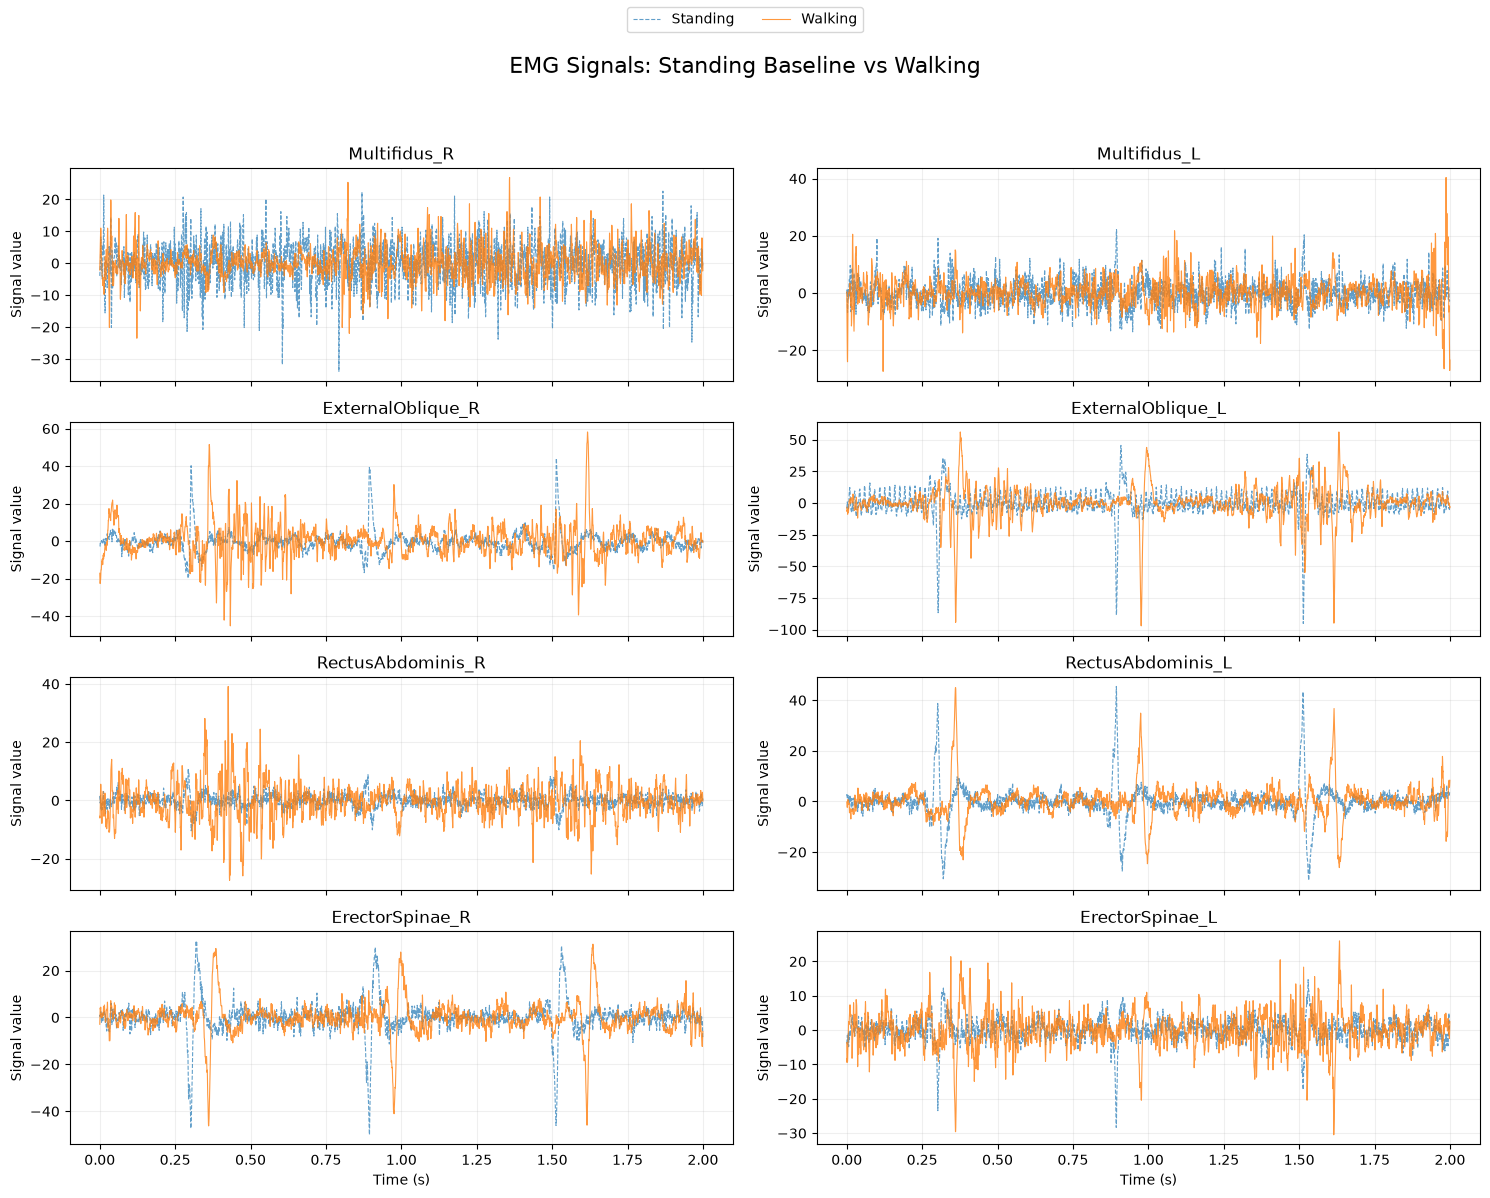

In [ ]:
def compare_emg_channels(standing, walking, cols, seconds=2.0):
    fig, axes = plt.subplots(
        nrows=4,
        ncols=2,
        figsize=(15, 12),
        sharex=True
    )
    axes = axes.flatten()

    for ax, col in zip(axes, cols):
        stand_part = standing[standing[time_col] <= standing[time_col].iloc[0] + seconds]
        walk_part = walking[walking[time_col] <= walking[time_col].iloc[0] + seconds]

        # Shift time so both start at 0
        stand_time = stand_part[time_col] - stand_part[time_col].iloc[0]
        walk_time = walk_part[time_col] - walk_part[time_col].iloc[0]

        # Plot both conditions
        ax.plot(
            stand_time,
            stand_part[col],
            label="Standing",
            linewidth=0.8,
            linestyle="--",
            alpha=0.7
        )
        ax.plot(
            walk_time,
            walk_part[col],
            label="Walking",
            linewidth=0.8,
            linestyle="-",
            alpha=0.8
        )
        ax.set_title(col)
        ax.set_ylabel("Signal value")
        ax.grid(alpha=0.2)

    # X label only needed at bottom
    for ax in axes[-2:]:
        ax.set_xlabel("Time (s)")

    # One shared legend
    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(
        handles,
        labels,
        loc="upper center",
        ncol=2
    )
    fig.suptitle(
        "\nEMG Signals: Standing Baseline vs Walking",
        fontsize=16,
        y=0.98
    )
    plt.tight_layout(rect=[0, 0, 1, 0.95])
    plt.show()

compare_emg_channels(
    standing,
    walking,
    emg_cols,
    seconds=2.0
)

## 5. Visualize bilateral thigh/shank/foot motion
Gyroscope signals are especially useful for seeing movement direction and repeated gait patterns.

In [ ]:
for segment in ['Thigh', 'Shank', 'Foot']:
    cols = [f'{segment}_L_Gyro_X', f'{segment}_L_Gyro_Y', f'{segment}_L_Gyro_Z',
            f'{segment}_R_Gyro_X', f'{segment}_R_Gyro_Y', f'{segment}_R_Gyro_Z']
    plot_channels(walking, cols, f"{segment} gyroscope — left vs right", seconds=walking[time_col].iloc[-1])

## 6. Baseline normalization
Subtract the mean standing value from every sensor channel. This treats standing as the neutral reference and makes walking values represent deviation from baseline.

In [ ]:
signal_cols = emg_cols + imu_cols
baseline_mean = standing[signal_cols].mean()

walking_zeroed = walking.copy()
walking_zeroed[signal_cols] = walking[signal_cols] - baseline_mean

display(walking_zeroed.head())

## 7. Temporary bilateral 0–50 regression targets
**Prototype only.** Because true hip angle is unavailable, we estimate a thigh tilt proxy from accelerometer orientation relative to the standing baseline, then scale observed walking excursion to 0–50.

This lets us test the software architecture, but it must not be reported as validated anatomical hip angle.

In [ ]:
def accel_tilt_deg(df, side):
    # Generic tilt magnitude from accelerometer. Axis convention must be verified for the real sensor setup.
    x = df[f'Thigh_{side}_Accel_X'].to_numpy()
    y = df[f'Thigh_{side}_Accel_Y'].to_numpy()
    z = df[f'Thigh_{side}_Accel_Z'].to_numpy()
    return np.degrees(np.arctan2(np.sqrt(x*x + y*y), z))

# Neutral orientation from standing baseline
neutral_L = np.nanmedian(accel_tilt_deg(standing, 'L'))
neutral_R = np.nanmedian(accel_tilt_deg(standing, 'R'))

walking_work = walking_zeroed.copy()
# Use RAW acceleration for orientation, then reference it to standing.
raw_tilt_L = accel_tilt_deg(walking, 'L')
raw_tilt_R = accel_tilt_deg(walking, 'R')

walking_work['TiltProxy_L_deg'] = np.abs(raw_tilt_L - neutral_L)
walking_work['TiltProxy_R_deg'] = np.abs(raw_tilt_R - neutral_R)

def scale_to_0_50(x):
    # Robust scaling: 95th percentile is treated as the observed high excursion.
    high = np.nanpercentile(x, 95)
    if high <= 0:
        return np.zeros_like(x)
    return np.clip(50.0 * x / high, 0, 50)

walking_work['TargetProxy_L'] = scale_to_0_50(walking_work['TiltProxy_L_deg'].to_numpy())
walking_work['TargetProxy_R'] = scale_to_0_50(walking_work['TiltProxy_R_deg'].to_numpy())

plt.plot(walking_work[time_col], walking_work['TargetProxy_L'], label='Left proxy')
plt.plot(walking_work[time_col], walking_work['TargetProxy_R'], label='Right proxy')
plt.title('Temporary bilateral control-position proxy (0–50)')
plt.xlabel('Time (s)')
plt.ylabel('Proxy control value')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 8. Feature engineering
The model itself is not forecasting. Rolling features summarize the **current/recent sensor condition** and can be removed if the team wants strictly instantaneous inputs.

Here we use raw zeroed signals plus short rolling mean and standard deviation.

In [ ]:
WINDOW = 20  # samples; adjust after confirming sampling rate/control loop
feature_base = signal_cols

features = walking_zeroed[feature_base].copy()
for c in feature_base:
    features[c + '_mean'] = walking_zeroed[c].rolling(WINDOW, min_periods=1).mean()
    features[c + '_std'] = walking_zeroed[c].rolling(WINDOW, min_periods=1).std().fillna(0)

features = features.replace([np.inf, -np.inf], np.nan).fillna(0)
print("Feature matrix:", features.shape)

## 9. Starter regression model
A Random Forest is used because it is a simple nonlinear baseline for tabular sensor features. We train one model per side.

**Important:** random splitting is acceptable only for this first prototype. For final evaluation, split by separate trials/subjects to avoid leakage between highly similar neighboring samples.

In [ ]:
X = features
idx_train, idx_test = train_test_split(np.arange(len(X)), test_size=0.25, random_state=RANDOM_STATE)

models = {}
predictions = {}

for side in ['L', 'R']:
    y = walking_work[f'TargetProxy_{side}'].to_numpy()
    model = RandomForestRegressor(
        n_estimators=120,
        max_depth=12,
        min_samples_leaf=3,
        random_state=RANDOM_STATE,
        n_jobs=-1
    )
    model.fit(X.iloc[idx_train], y[idx_train])
    pred = np.clip(model.predict(X.iloc[idx_test]), 0, 50)
    models[side] = model
    predictions[side] = pred

    print(f"
{side} regression")
    print("MAE :", round(mean_absolute_error(y[idx_test], pred), 3))
    print("RMSE:", round(np.sqrt(mean_squared_error(y[idx_test], pred)), 3))
    print("R²  :", round(r2_score(y[idx_test], pred), 3))

## 10. Visualize regression output

In [ ]:
order = np.argsort(idx_test)
for side in ['L', 'R']:
    y = walking_work[f'TargetProxy_{side}'].to_numpy()
    plt.figure(figsize=(14,4))
    plt.plot(walking_work[time_col].iloc[idx_test[order]], y[idx_test[order]], label='Proxy target', linewidth=1)
    plt.plot(walking_work[time_col].iloc[idx_test[order]], predictions[side][order], label='Regression output', linewidth=1)
    plt.title(f'{side} side — regression proxy target vs output')
    plt.xlabel('Time (s)')
    plt.ylabel('0–50 control value')
    plt.legend()
    plt.grid(alpha=0.2)
    plt.show()

## 11. Convert regression output into discrete motor states
Ten 5-unit bins are used initially. This is **deterministic state mapping**, not a second ML model.

- S0: [0,5)
- S1: [5,10)
- ...
- S9: [45,50]

In [ ]:
def value_to_state(value, step=5, max_state=9):
    value = np.clip(value, 0, 50)
    return int(min(value // step, max_state))

# Generate predictions for the complete walking sequence for transition analysis.
for side in ['L', 'R']:
    walking_work[f'PredValue_{side}'] = np.clip(models[side].predict(X), 0, 50)
    walking_work[f'State_{side}'] = walking_work[f'PredValue_{side}'].apply(value_to_state)

walking_work[[time_col, 'PredValue_L', 'State_L', 'PredValue_R', 'State_R']].head(20)

## 12. Visualize left/right state progression
This is the important time-series use in the proposed design: **observe how accepted states change over time**, rather than predict a future state.

In [ ]:
plt.figure(figsize=(14,5))
plt.step(walking_work[time_col], walking_work['State_L'], where='post', label='Left state')
plt.step(walking_work[time_col], walking_work['State_R'], where='post', label='Right state')
plt.yticks(range(10), [f'S{i}' for i in range(10)])
plt.xlabel('Time (s)')
plt.ylabel('Control state')
plt.title('Bilateral state transitions')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 13. Bilateral transition / fault-detection prototype
The validator considers **both hips together**. A candidate state can be rejected when:
1. either side jumps too many states in one control update;
2. both sides simultaneously make a large forward jump;
3. optional rapid direction reversal occurs.

The thresholds below are placeholders and should later be justified using the real gait data and the motor/control update interval.

In [ ]:
MAX_STATE_JUMP = 2
BILATERAL_LARGE_FORWARD = 2

def transition_check(prev_l, prev_r, curr_l, curr_r):
    dl = curr_l - prev_l
    dr = curr_r - prev_r
    reasons = []

    if abs(dl) > MAX_STATE_JUMP:
        reasons.append(f'left jump {dl:+d}')
    if abs(dr) > MAX_STATE_JUMP:
        reasons.append(f'right jump {dr:+d}')

    # Bilateral coordination safeguard: both sides should not suddenly demand
    # a large forward advance together.
    if dl >= BILATERAL_LARGE_FORWARD and dr >= BILATERAL_LARGE_FORWARD:
        reasons.append('simultaneous large bilateral forward jump')

    return len(reasons) == 0, '; '.join(reasons)

accepted_l = [int(walking_work['State_L'].iloc[0])]
accepted_r = [int(walking_work['State_R'].iloc[0])]
faults = [False]
reasons = ['']

for i in range(1, len(walking_work)):
    cand_l = int(walking_work['State_L'].iloc[i])
    cand_r = int(walking_work['State_R'].iloc[i])
    ok, reason = transition_check(accepted_l[-1], accepted_r[-1], cand_l, cand_r)

    if ok:
        accepted_l.append(cand_l)
        accepted_r.append(cand_r)
        faults.append(False)
        reasons.append('')
    else:
        # Safe prototype behavior: hold the last accepted bilateral state.
        accepted_l.append(accepted_l[-1])
        accepted_r.append(accepted_r[-1])
        faults.append(True)
        reasons.append(reason)

walking_work['AcceptedState_L'] = accepted_l
walking_work['AcceptedState_R'] = accepted_r
walking_work['Fault'] = faults
walking_work['FaultReason'] = reasons

print('Flagged transitions:', int(walking_work['Fault'].sum()))
display(walking_work.loc[walking_work['Fault'],
    [time_col, 'State_L','State_R','AcceptedState_L','AcceptedState_R','FaultReason']].head(20))

## 14. Visualize accepted states and faults

In [ ]:
plt.figure(figsize=(14,5))
plt.step(walking_work[time_col], walking_work['AcceptedState_L'], where='post', label='Accepted left')
plt.step(walking_work[time_col], walking_work['AcceptedState_R'], where='post', label='Accepted right')

fault_rows = walking_work[walking_work['Fault']]
if len(fault_rows):
    plt.scatter(fault_rows[time_col], fault_rows['AcceptedState_L'], marker='x', label='Flagged transition')

plt.yticks(range(10), [f'S{i}' for i in range(10)])
plt.xlabel('Time (s)')
plt.ylabel('Accepted state')
plt.title('Bilateral accepted state sequence with transition faults')
plt.legend()
plt.grid(alpha=0.2)
plt.show()

## 15. Transition matrix — learn what the recorded gait actually does
Instead of inventing every valid bilateral transition, count which `(Left state, Right state)` pairs and transitions appear in the walking trial. With more trials, this can become the basis for a data-driven allowed-transition table.

In [ ]:
pairs = list(zip(walking_work['AcceptedState_L'], walking_work['AcceptedState_R']))
transition_counts = {}
for a, b in zip(pairs[:-1], pairs[1:]):
    key = (a, b)
    transition_counts[key] = transition_counts.get(key, 0) + 1

transition_table = pd.DataFrame([
    {'From_L': a[0], 'From_R': a[1], 'To_L': b[0], 'To_R': b[1], 'Count': count}
    for (a, b), count in transition_counts.items()
]).sort_values('Count', ascending=False)

display(transition_table.head(25))

## 16. Optional state-classification evaluation
Because the regression output is ultimately quantized, evaluate whether the predicted proxy and target proxy land in the same state. This is often more meaningful for the motor controller than angle/proxy error alone.

In [ ]:
for side in ['L','R']:
    true_states = walking_work[f'TargetProxy_{side}'].apply(value_to_state)
    pred_states = walking_work[f'PredValue_{side}'].apply(value_to_state)
    print(side, 'state agreement:', round(accuracy_score(true_states, pred_states), 4))

## 17. Feature importance — initial analysis only
This can help identify which EMG/IMU measurements the Random Forest uses most. Feature importance does **not** prove physiological causality.

In [ ]:
for side in ['L','R']:
    imp = pd.Series(models[side].feature_importances_, index=X.columns).sort_values(ascending=False).head(20)
    plt.figure(figsize=(10,6))
    imp.sort_values().plot(kind='barh')
    plt.title(f'Top Random Forest features — {side} proxy')
    plt.xlabel('Feature importance')
    plt.tight_layout()
    plt.show()

## 18. Export prototype results
This produces a CSV containing candidate/accepted states and fault flags for later inspection or motor-interface prototyping.

In [ ]:
output_cols = [time_col, 'PredValue_L','State_L','AcceptedState_L',
               'PredValue_R','State_R','AcceptedState_R','Fault','FaultReason']
walking_work[output_cols].to_csv('prototype_bilateral_states.csv', index=False)
print('Saved prototype_bilateral_states.csv')

# What should be improved next?

1. **Do not present `TargetProxy_L/R` as true hip angles.** They are placeholders created only because the current files lack ground-truth joint angle.
2. Verify IMU units, axis orientation, and sensor mounting before interpreting tilt physically.
3. Decide whether the final ML input should use all IMUs, EMG only, or selected features.
4. Analyze several walking trials/subjects before defining the final number of states.
5. Replace random train/test splitting with trial-wise or subject-wise splitting when more recordings exist.
6. Determine valid **bilateral** state combinations/transitions from repeated gait data rather than relying only on hand-written rules.
7. Add transition timing constraints (states/second or degrees/second equivalent) once the motor/control update rate is known.
8. Consider classifier baselines (Random Forest/XGBoost) if the final target becomes directly labeled discrete states rather than a continuous control variable.
9. Add a safe hold/neutral policy for invalid, noisy, or low-confidence classifications.

The architectural separation should remain:

`Sensor analysis → model output → state mapping → bilateral transition validator → fault handling → motor command`